# Phase 0: mechanistic reproduction of the invariant case

This notebook tests the reduced Phase 0 hypothesis from `RESEARCH_BRIEF.md`:

> A temporal JEPA trained on dynamically immiscible regimes can learn a non-collapsed representation that separates regimes, while an identity-initialized linear predictor acts approximately as the identity on the active latent subspace.

This is **one full baseline run (seed 0)**, not yet a multi-seed reproduction and not an exact replication of every number in the paper. The random-initialization control will be run separately after inspecting this baseline.

In [1]:
import json
import platform
from pathlib import Path

import numpy as np
import torch
from IPython.display import Image, Markdown, display

from koopman_jepa.config import load_config
from koopman_jepa.phase0 import run

ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
assert (ROOT / "pyproject.toml").exists(), "Could not locate the repository root."

print(f"Python: {platform.python_version()}")
print(f"PyTorch: {torch.__version__}")
print(f"NumPy: {np.__version__}")

Python: 3.13.12
PyTorch: 2.14.0
NumPy: 2.5.3


## Protocol and decision rule

The run uses the committed smoke configuration at its full 30 epochs: six synthetic regimes, 600 training pairs per regime, an EMA target encoder, and an identity-initialized predictor. CPU is selected for reproducibility.

The current Gate 0 thresholds are:

- effective rank $\geq 2$ (non-collapse);
- held-out linear-probe accuracy $\geq 0.80$;
- active centroid rank $\geq 3$;
- online/target centroid relative error $\leq 0.25$;
- predictor identity error on the active subspace $\leq 0.25$.

In [2]:
config = load_config(ROOT / "configs" / "phase0_smoke.yaml")
config.model.predictor_init = "identity"
config.train.seed = 0
config.train.epochs = 30
config.train.device = "cpu"
config.output_dir = str(ROOT / "runs" / "phase0")
config.to_dict()

{'data': {'context_length': 128,
  'shift': 32,
  'train_per_regime': 600,
  'val_per_regime': 120,
  'test_per_regime': 120,
  'noise_std': 0.03,
  'standardize': True},
 'model': {'latent_dim': 8,
  'channels': [16, 32, 64],
  'predictor_init': 'identity'},
 'train': {'seed': 0,
  'epochs': 30,
  'batch_size': 128,
  'learning_rate': 0.001,
  'weight_decay': 0.0001,
  'ema_momentum': 0.99,
  'variance_weight': 0.0,
  'covariance_weight': 0.0,
  'device': 'cpu',
  'num_workers': 0},
 'output_dir': '/Users/micolmichanie/Documents/koopman-jepa/runs/phase0'}

## Train and evaluate

The runner writes the complete artifact bundle under `runs/phase0/`. That directory is ignored by Git; the important numerical and visual outputs are embedded below when this notebook is executed.

In [3]:
run_dir = run(config)
run_dir

device=cpu
run_dir=/Users/micolmichanie/Documents/koopman-jepa/runs/phase0/seed000_identity_20260919T110949Z


epoch=001 train=0.000038 val=0.000011


epoch=006 train=0.000005 val=0.000005


epoch=012 train=0.000003 val=0.000003


epoch=018 train=0.000002 val=0.000002


epoch=024 train=0.000001 val=0.000002


epoch=030 train=0.000001 val=0.000001


{
  "effective_rank": 4.556973457336426,
  "linear_probe_accuracy": 0.9708333333333333,
  "kmeans_purity": 0.6402777777777777,
  "active_rank": 6,
  "active_identity_error": 0.021379647202565678,
  "active_eigenvalue_one_error": 0.014547924511134624,
  "online_target_centroid_error": 0.006751847453415394,
  "all_run_checks_passed": true
}


PosixPath('/Users/micolmichanie/Documents/koopman-jepa/runs/phase0/seed000_identity_20260919T110949Z')

## Numerical results

In [4]:
metrics = json.loads((run_dir / "metrics.json").read_text(encoding="utf-8"))
reported = {
    "effective_rank": metrics["effective_rank"],
    "embedding_std_mean": metrics["embedding_std_mean"],
    "between_within_ratio": metrics["between_within_ratio"],
    "linear_probe_accuracy": metrics["linear_probe_accuracy"],
    "nearest_centroid_accuracy": metrics["nearest_centroid_accuracy"],
    "kmeans_purity": metrics["kmeans_purity"],
    "kmeans_matched_accuracy": metrics["kmeans_matched_accuracy"],
    "active_rank": metrics["active_rank"],
    "active_identity_error": metrics["active_identity_error"],
    "active_eigenvalue_one_error": metrics["active_eigenvalue_one_error"],
    "active_invariance_error": metrics["active_invariance_error"],
    "online_target_centroid_error": metrics["online_target_centroid_error"],
}

table = ["| metric | value |", "|---|---:|"]
for name, value in reported.items():
    rendered = "undefined" if value is None else f"{value:.6f}"
    table.append(f"| `{name}` | {rendered} |")
display(Markdown("\n".join(table)))

| metric | value |
|---|---:|
| `effective_rank` | 4.556973 |
| `embedding_std_mean` | 0.006033 |
| `between_within_ratio` | 0.952968 |
| `linear_probe_accuracy` | 0.970833 |
| `nearest_centroid_accuracy` | 0.818056 |
| `kmeans_purity` | 0.640278 |
| `kmeans_matched_accuracy` | 0.586111 |
| `active_rank` | 6.000000 |
| `active_identity_error` | 0.021380 |
| `active_eigenvalue_one_error` | 0.014548 |
| `active_invariance_error` | 0.008942 |
| `online_target_centroid_error` | 0.006752 |

In [5]:
gate_table = ["| Gate 0 check | passed |", "|---|:---:|"]
for name, passed in metrics["gate_checks"].items():
    gate_table.append(f"| `{name}` | {'yes' if passed else 'no'} |")
display(Markdown("\n".join(gate_table)))

active_eigenvalues = [
    complex(value["real"], value["imag"])
    for value in metrics["active_eigenvalues"]
]
print("Active-subspace eigenvalues:")
for value in active_eigenvalues:
    print(f"  {value.real:+.6f}{value.imag:+.6f}j")

| Gate 0 check | passed |
|---|:---:|
| `active_rank_at_least_three` | yes |
| `identity_on_active_subspace` | yes |
| `noncollapsed` | yes |
| `online_target_aligned` | yes |
| `regimes_separable` | yes |

Active-subspace eigenvalues:
  +0.957583+0.000000j
  +0.981956+0.000000j
  +0.986710+0.000000j
  +0.991941+0.000000j
  +0.995866+0.000000j
  +0.998656+0.000000j


## Visual diagnostics

### Training curves

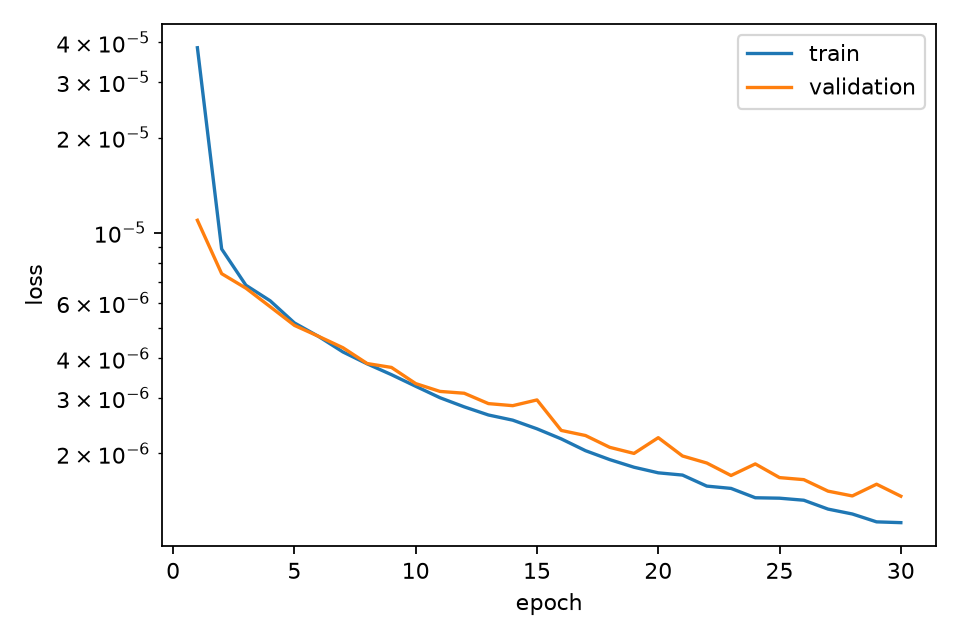

### Held-out embeddings (PCA)

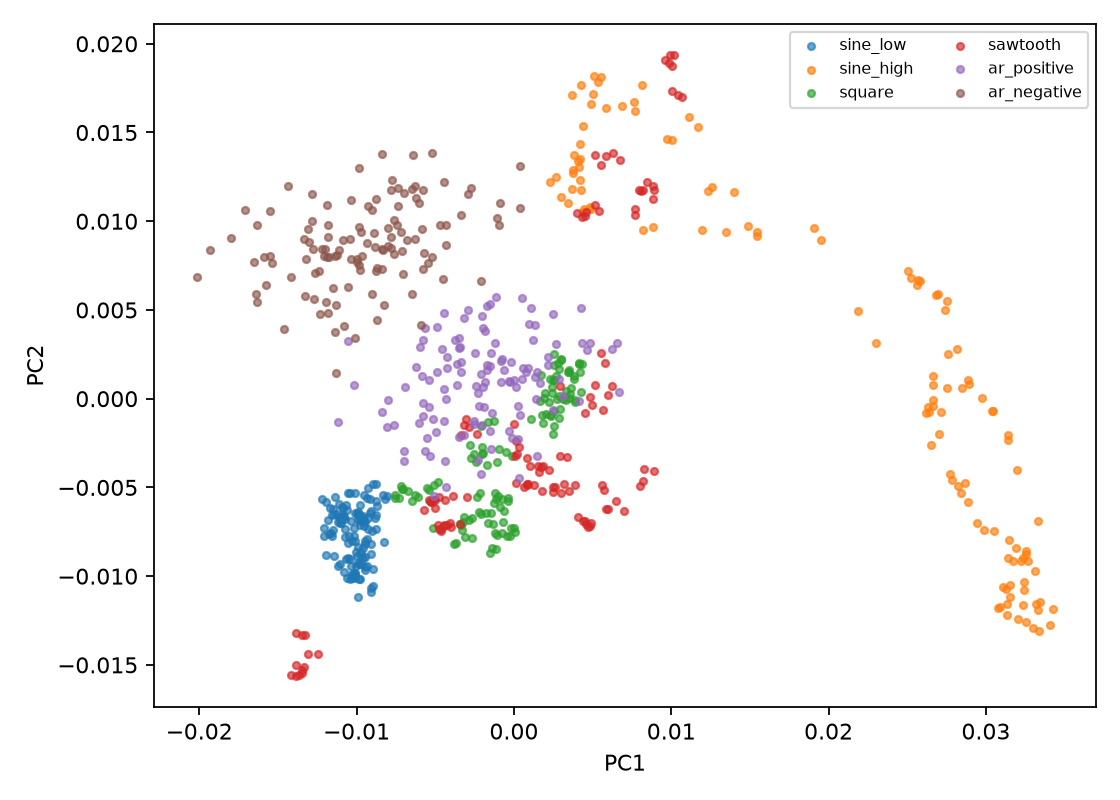

### Predictor spectrum

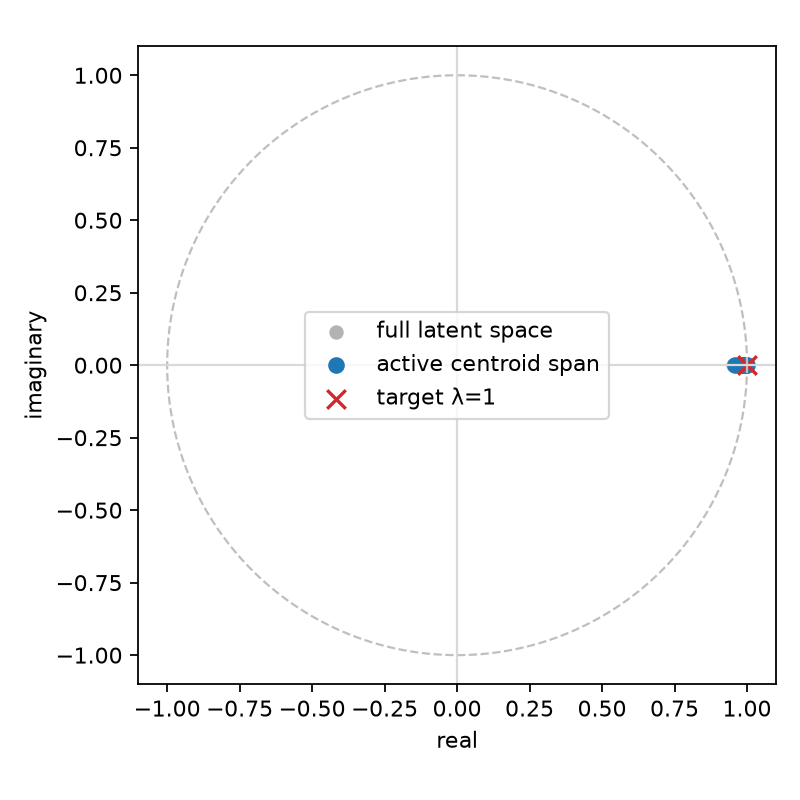

In [6]:
for title, filename in (
    ("Training curves", "loss.png"),
    ("Held-out embeddings (PCA)", "embeddings_pca.png"),
    ("Predictor spectrum", "predictor_spectrum.png"),
):
    display(Markdown(f"### {title}"))
    display(Image(filename=str(run_dir / filename)))

## Interpretation

Passing every check would be evidence that this implementation reproduces the paper's invariant mechanism **qualitatively for one seed**. It would not yet establish robustness. Failing a check is also informative: it identifies whether the issue is collapse, regime identifiability, target alignment, insufficient active rank, or non-identity predictor action.

In [7]:
if metrics["all_run_checks_passed"]:
    conclusion = (
        "**Operational result:** all current Gate 0 thresholds passed for seed 0. "
        f"This is partial evidence, not yet a reproduction claim: K-means purity is "
        f"{metrics['kmeans_purity']:.3f} and mean embedding std is "
        f"{metrics['embedding_std_mean']:.4g}. Next: inspect these diagnostics, then "
        "run the random-initialization control and multiple seeds."
    )
else:
    failed = [name for name, passed in metrics["gate_checks"].items() if not passed]
    conclusion = (
        "**Baseline result:** Gate 0 did not pass for seed 0. "
        f"Failed checks: {', '.join(failed)}. "
        "We should diagnose these failures before running a seed sweep."
    )
display(Markdown(conclusion))

**Operational result:** all current Gate 0 thresholds passed for seed 0. This is partial evidence, not yet a reproduction claim: K-means purity is 0.640 and mean embedding std is 0.006033. Next: inspect these diagnostics, then run the random-initialization control and multiple seeds.